# ALBERT Fine-Tuning (Colab A100 GPU)

## Setup

In [1]:
## IMPORTS
import sys

if "google.colab" in sys.modules:
    from google.colab import drive

    drive.mount("/content/drive")
# my root project folder inside google drive
    sys.path.append('/content/drive/MyDrive/di504')


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import sklearn

from src.utils.seeding import set_global_seed
from config import *


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
## ENVIRONMENT CHECK
print(torch.__version__)
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No GPU")


2.11.0+cu128
True
NVIDIA A100-SXM4-40GB


In [ ]:
# to install optuna to Colab environment
!pip install -q transformers optuna nlpaug

In [6]:
from pathlib import Path
import pandas as pd

preprocessed_df_cache_file_location = PROCESSED_DATA_DIR / "preprocessed_df.csv"
df = pd.read_csv(str(preprocessed_df_cache_file_location))

from src.data.splits import split_data
train_df, val_df, test_df = split_data(df, label_column='encoded_status', random_state=GLOBAL_SEED)

train: (31516, 5), 0.600 of total
val:   (10505, 5), 0.200 of total
test:  (10506, 5), 0.200 of total

train class distribution:
encoded_status
0    0.073137
1    0.052862
2    0.293089
3    0.308510
4    0.020498
5    0.049213
6    0.202691
Name: proportion, dtype: float64

val class distribution:
encoded_status
0    0.073108
1    0.052832
2    0.293099
3    0.308520
4    0.020562
5    0.049215
6    0.202665
Name: proportion, dtype: float64

test class distribution:
encoded_status
0    0.073101
1    0.052922
2    0.293071
3    0.308586
4    0.020464
5    0.049210
6    0.202646
Name: proportion, dtype: float64


In [8]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"device is {device}")

device is cuda


## Section 15 — ALBERT Preprocessing

In [9]:
from transformers import AlbertTokenizer
from src.models.albert_dataset import SentimentDataset
from torch.utils.data import DataLoader

tokenizer = AlbertTokenizer.from_pretrained(ALBERT_MODEL_NAME)

train_dataset = SentimentDataset(
    train_df['statement_seq'].tolist(),
    train_df['encoded_status'].tolist(),
    tokenizer,
    max_len=ALBERT_MAX_LEN
)
val_dataset = SentimentDataset(
    val_df['statement_seq'].tolist(),
    val_df['encoded_status'].tolist(),
    tokenizer,
    max_len=ALBERT_MAX_LEN
)
test_dataset = SentimentDataset(
    test_df['statement_seq'].tolist(),
    test_df['encoded_status'].tolist(),
    tokenizer,
    max_len=ALBERT_MAX_LEN
)

train_loader = DataLoader(train_dataset, batch_size=ALBERT_BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=ALBERT_BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=ALBERT_BATCH_SIZE, shuffle=False)

batch = next(iter(train_loader))
print(batch['input_ids'].shape)       # expect torch.Size([4, 200])
print(batch['attention_mask'].shape)  # expect torch.Size([4, 200])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


torch.Size([16, 200])
torch.Size([16, 200])


In [10]:
print(f"train: {len(train_dataset)}, val: {len(val_dataset)}, test: {len(test_dataset)}")

train: 31516, val: 10505, test: 10506


## Section 16 — ALBERT Fine-Tuning with Random Search

In [11]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from src.training.tune_albert import run_albert_search
import time

class_weights_np = compute_class_weight(
    'balanced',
    classes=np.unique(train_df['encoded_status']),
    y=train_df['encoded_status']
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print(class_weights)




start = time.time()
best_albert_model, best_params, best_val_f1, train_losses, val_losses, results = run_albert_search(
    train_dataset, val_dataset, class_weights, device, n_iter=10
)
elapsed = time.time() - start
print(f"Total search time: {elapsed/60:.1f} minutes")
print("Best params:", best_params)
print("Best val weighted F1:", best_val_f1)



tensor([1.9533, 2.7025, 0.4874, 0.4631, 6.9695, 2.9028, 0.7048],
       device='cuda:0')

--- Trial 1/10: {'lr': 1.5542448978618584e-05, 'epochs': 5, 'dropout': 0.4271353764466278} ---


config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/47.4M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 - train_loss: 1.9731, val_loss: 1.9699, val_f1: 0.0683
Epoch 2/5 - train_loss: 1.9063, val_loss: 1.9421, val_f1: 0.0046
Epoch 3/5 - train_loss: 1.9666, val_loss: 1.9447, val_f1: 0.1329
Epoch 4/5 - train_loss: 1.9648, val_loss: 1.9491, val_f1: 0.0053
Epoch 5/5 - train_loss: 1.9632, val_loss: 1.9600, val_f1: 0.1455
Trial 9 took 26.5 minutes

--- Trial 10/10: {'lr': 4.48103301026688e-05, 'epochs': 5, 'dropout': 0.41624884103785786} ---


Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
classifier.bias              | MISSING    | 
classifier.weight            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch 1/5 - train_loss: 1.9454, val_loss: 1.9429, val_f1: 0.1328
Epoch 2/5 - train_loss: 1.9438, val_loss: 1.9405, val_f1: 0.0683
Epoch 3/5 - train_loss: 1.9467, val_loss: 1.9417, val_f1: 0.1329
Epoch 4/5 - train_loss: 1.9453, val_loss: 1.9384, val_f1: 0.1329
Epoch 5/5 - train_loss: 1.9440, val_loss: 1.9399, val_f1: 0.1455
Trial 10 took 26.5 minutes

All trials, sorted by val F1:
{'lr': 1.1376101256261965e-05, 'epochs': 3, 'dropout': 0.1088575654412109} -> val F1: 0.7791
{'lr': 1.8732364735390046e-05, 'epochs': 5, 'dropout': 0.17940750361046842} -> val F1: 0.7149
{'lr': 4.093661181026368e-05, 'epochs': 4, 'dropout': 0.4119903232475214} -> val F1: 0.6669
{'lr': 2.1429667283590285e-05, 'epochs': 5, 'dropout': 0.1393007742202168} -> val F1: 0.6427
{'lr': 1.5542448978618584e-05, 'epochs': 5, 'dropout': 0.4271353764466278} -> val F1: 0.4651
{'lr': 1.953118318157018e-05, 'epochs': 3, 'dropout': 0.45569045268112796} -> val F1: 0.4565
{'lr': 2.2793828165373322e-05, 'epochs': 3, 'dropout': 0.29

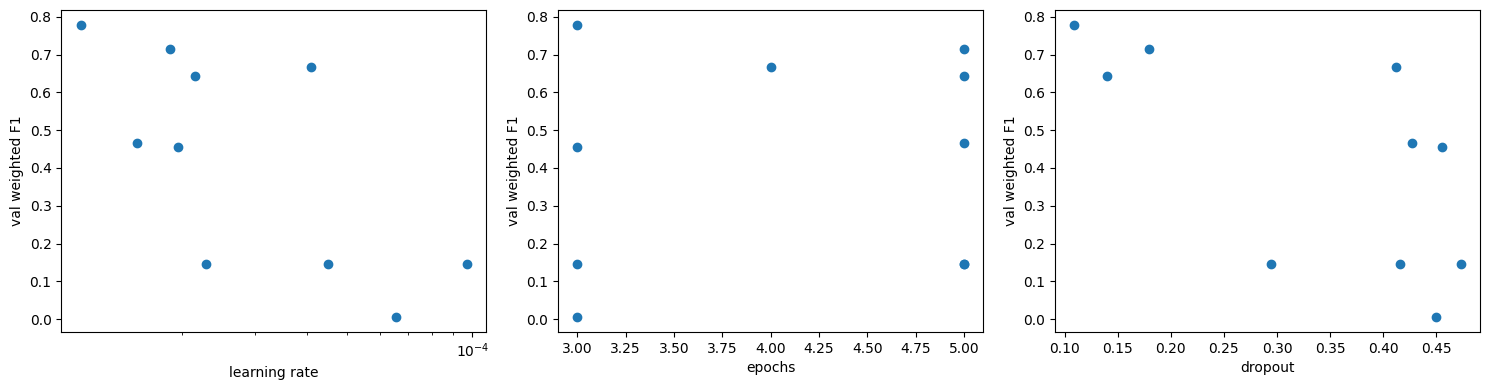

In [ ]:
### 

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

lrs = [p['lr'] for p, f1 in results]
epochs_list = [p['epochs'] for p, f1 in results]
dropouts = [p['dropout'] for p, f1 in results]
f1s = [f1 for p, f1 in results]

axes[0].scatter(lrs, f1s)
axes[0].set_xscale('log')
axes[0].set_xlabel('learning rate')
axes[0].set_ylabel('val weighted F1')

axes[1].scatter(epochs_list, f1s)
axes[1].set_xlabel('epochs')
axes[1].set_ylabel('val weighted F1')

axes[2].scatter(dropouts, f1s)
axes[2].set_xlabel('dropout')
axes[2].set_ylabel('val weighted F1')

plt.tight_layout()
plt.show()

## Section 17 — ALBERT Evaluation

ALBERT weighted F1 = 0.7777117479904891 (np.float64(0.7694491904593393), np.float64(0.7853594722310319))
ALBERT macro AUROC = 0.9680815503575406 (np.float64(0.9659999247589518), np.float64(0.9699725911758965))


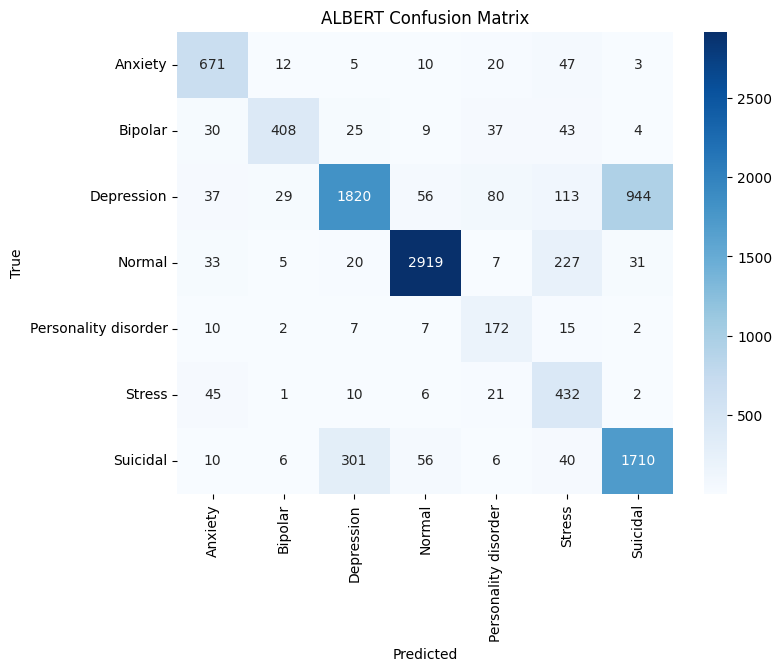

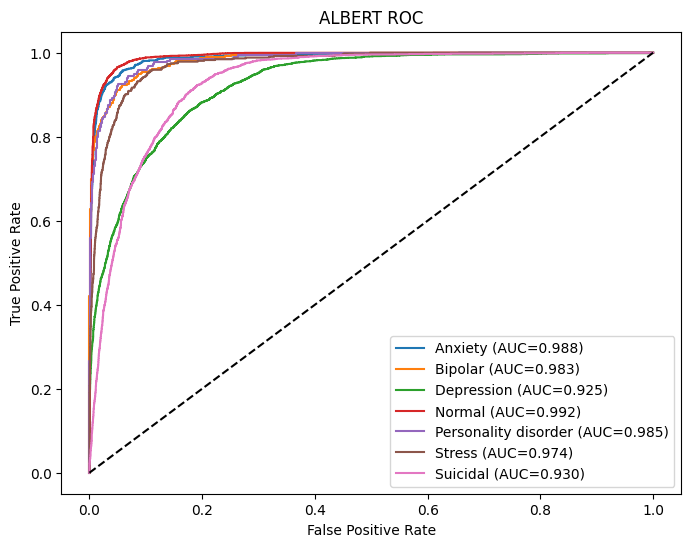

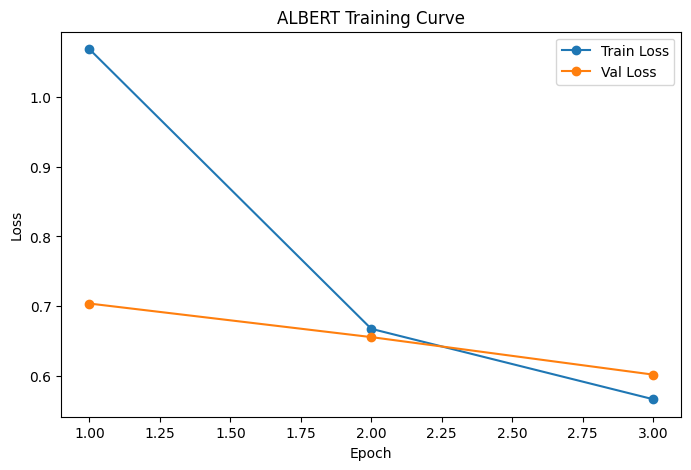

In [13]:
from src.evaluation.evaluate_pytorch import evaluate_pytorch_model
from src.utils.viz import plot_confusion_matrix, plot_roc_curves, plot_training_curves

albert_results = evaluate_pytorch_model(
    best_albert_model, test_loader, device, CLASS_NAMES, use_attention_mask=True
)

print("ALBERT weighted F1 =", albert_results['weighted_f1'], albert_results['weighted_f1_ci'])
print("ALBERT macro AUROC =", albert_results['macro_auroc'], albert_results['macro_auroc_ci'])

plot_confusion_matrix(albert_results['confusion_matrix'], CLASS_NAMES, title="ALBERT Confusion Matrix",save_path=str(RESULTS_DIR / "albert_confusion_matrix.png"))
plot_roc_curves(albert_results['y_true'], albert_results['y_proba'], CLASS_NAMES, title="ALBERT ROC",save_path=str(RESULTS_DIR / "albert_roc.png"))
plot_training_curves(train_losses, val_losses, title="ALBERT Training Curve",save_path=str(RESULTS_DIR / "albert_training_curve.png"))

## Save & Export

In [ ]:
import pickle

# save model results so they can be used in the main notebook
model_save_path = MODELS_DIR / "best_albert_model.pth"
torch.save(best_albert_model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

## save albert results as pickle inside "outputs" directory 
results_save_path = RESULTS_DIR / "albert_results.pkl"
with open(results_save_path, "wb") as f:
    pickle.dump(albert_results, f)
print(f"Results saved to {results_save_path}")


# loss histories are saved as well, in case of re plotting Albert's training curve
loss_history_save_path = RESULTS_DIR / "albert_loss_history.pkl"
with open(loss_history_save_path, "wb") as f:
    pickle.dump({'train_losses': train_losses, 'val_losses': val_losses}, f)
print(f"Loss history saved to {loss_history_save_path}")

# Verification — reload everything fresh, in a NEW set of variable names,
# to confirm the files actually round-trip correctly before trusting them.
with open(results_save_path, "rb") as f:
    reloaded_results = pickle.load(f)
print("Reloaded weighted_f1:", reloaded_results['weighted_f1'])
print("Reloaded keys match original:", set(reloaded_results.keys()) == set(albert_results.keys()))

with open(loss_history_save_path, "rb") as f:
    reloaded_loss_history = pickle.load(f)
print("Reloaded loss history epochs:", len(reloaded_loss_history['train_losses']))

Model saved to /content/drive/MyDrive/di504/outputs/models/best_albert_model.pth
Results saved to /content/drive/MyDrive/di504/outputs/results/albert_results.pkl
Loss history saved to /content/drive/MyDrive/di504/outputs/results/albert_loss_history.pkl
Reloaded weighted_f1: 0.7777117479904891
Reloaded keys match original: True
Reloaded loss history epochs: 3
